# Introdução às Tecnicas de Classificacao

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

FIG_DIR = Path("figuras_classificacao")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RNG = np.random.default_rng(42)

def savefig(name):
    plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()

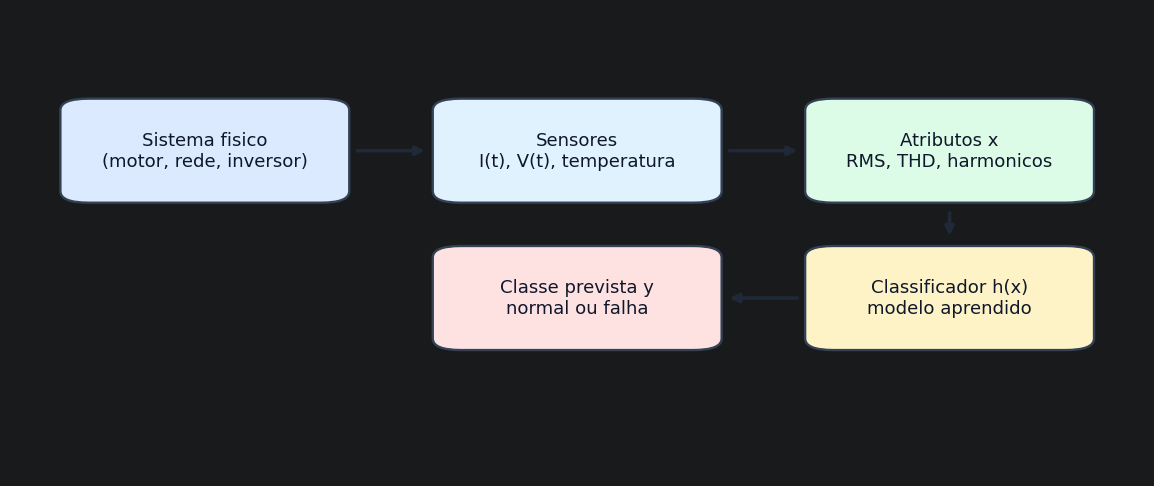

In [3]:
# Figura 1: fluxo basico de um problema de classificacao.
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(11.2, 4.6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

box_w, box_h = 0.22, 0.19
boxes = [
    (0.17, 0.70, "Sistema fisico\n(motor, rede, inversor)", "#dbeafe"),
    (0.50, 0.70, "Sensores\nI(t), V(t), temperatura", "#e0f2fe"),
    (0.83, 0.70, "Atributos x\nRMS, THD, harmonicos", "#dcfce7"),
    (0.83, 0.38, "Classificador h(x)\nmodelo aprendido", "#fef3c7"),
    (0.50, 0.38, "Classe prevista y\nnormal ou falha", "#fee2e2"),
]

for x, y, text, color in boxes:
    patch = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.018,rounding_size=0.025",
        fc=color,
        ec="#334155",
        lw=1.3,
    )
    ax.add_patch(patch)
    ax.text(x, y, text, ha="center", va="center", fontsize=10, color="#0f172a")

arrow_kw = dict(arrowstyle="-|>", lw=2.0, color="#1f2937", shrinkA=0, shrinkB=0)
arrows = [
    ((0.17 + box_w / 2 + 0.025, 0.70), (0.50 - box_w / 2 - 0.025, 0.70)),
    ((0.50 + box_w / 2 + 0.025, 0.70), (0.83 - box_w / 2 - 0.025, 0.70)),
    ((0.83, 0.70 - box_h / 2 - 0.040), (0.83, 0.38 + box_h / 2 + 0.040)),
    ((0.83 - box_w / 2 - 0.025, 0.38), (0.50 + box_w / 2 + 0.025, 0.38)),
]
for start, end in arrows:
    ax.annotate("", xy=end, xytext=start, arrowprops=arrow_kw)

savefig("fluxo_classificacao")

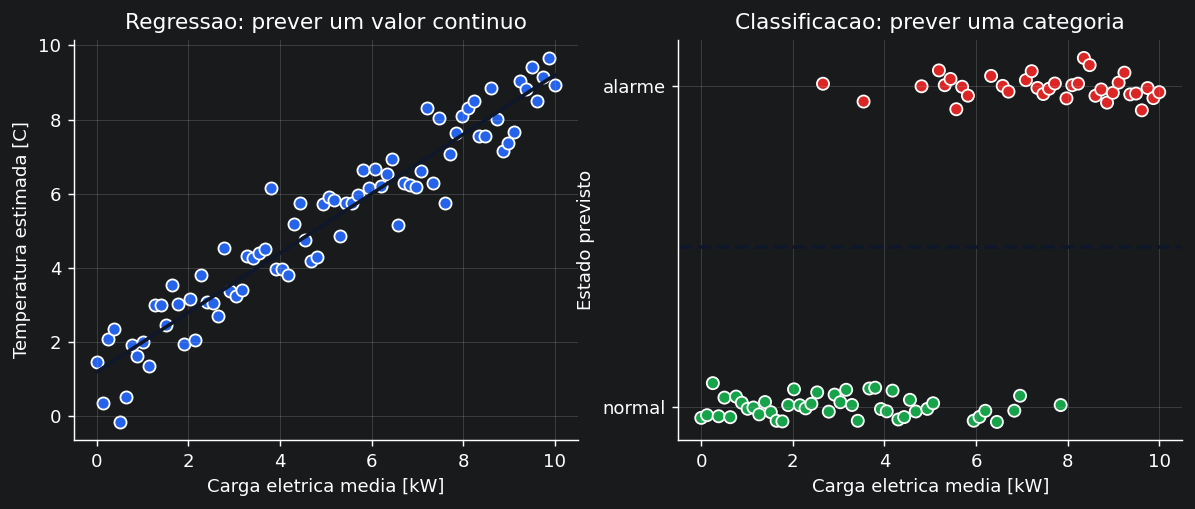

In [4]:
# Figura 2: diferenca entre regressao e classificacao.
n = 80
x = np.linspace(0, 10, n)
y_reg = 0.8 * x + 1.2 + RNG.normal(0, 0.9, size=n)
score = 0.8 * x + RNG.normal(0, 1.8, size=n)
y_cls = (score > 4.2).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

axes[0].scatter(x, y_reg, c="#2563eb", edgecolor="white", s=45)
axes[0].plot(x, 0.8 * x + 1.2, color="#0f172a", lw=2)
axes[0].set_title("Regressao: prever um valor continuo")
axes[0].set_xlabel("Carga eletrica media [kW]")
axes[0].set_ylabel("Temperatura estimada [C]")

colors = np.array(["#16a34a", "#dc2626"])
axes[1].scatter(x, y_cls + RNG.normal(0, 0.035, size=n), c=colors[y_cls], edgecolor="white", s=45)
axes[1].axhline(0.5, color="#0f172a", lw=2, ls="--")
axes[1].set_yticks([0, 1], ["normal", "alarme"])
axes[1].set_title("Classificacao: prever uma categoria")
axes[1].set_xlabel("Carga eletrica media [kW]")
axes[1].set_ylabel("Estado previsto")

savefig("regressao_vs_classificacao")

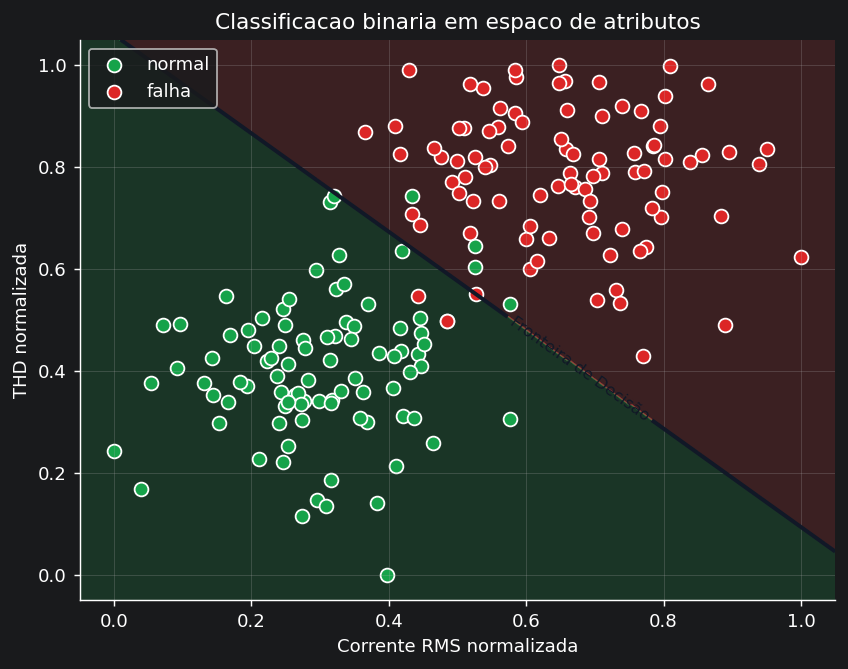

In [5]:
# Figura 3: fronteira de decisao em um espaco de atributos.
X, y = make_blobs(
    n_samples=180,
    centers=[(2.5, 2.2), (5.4, 5.0)],
    cluster_std=[1.0, 1.1],
    random_state=10,
)

# Normalizacao dos atributos
X = MinMaxScaler().fit_transform(X)

# Reinterpretacao didatica dos eixos para Engenharia Eletrica:
# x1 = corrente RMS normalizada; x2 = distorcao harmonica total normalizada.
clf = LogisticRegression().fit(X, y)

x_min, x_max = X[:, 0].min() - 0.05, X[:, 0].max() + 0.05
y_min, y_max = X[:, 1].min() - 0.05, X[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 350), np.linspace(y_min, y_max, 350))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
proba = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7.5, 5.6))
ax.contourf(xx, yy, Z, alpha=0.16, cmap=ListedColormap(["#22c55e", "#ef4444"]))
cs = ax.contour(xx, yy, proba, levels=[0.5], colors="#111827", linewidths=2.2)
ax.clabel(cs, fmt={0.5: "Fronteira de Decisão"}, inline=True, fontsize=9)
ax.scatter(X[y == 0, 0], X[y == 0, 1], c="#16a34a", edgecolor="white", s=58, label="normal")
ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#dc2626", edgecolor="white", s=58, label="falha")
ax.set_xlabel("Corrente RMS normalizada")
ax.set_ylabel("THD normalizada")
ax.set_title("Classificacao binaria em espaco de atributos")
ax.legend(frameon=True, loc="upper left")
savefig("fronteira_decisao")

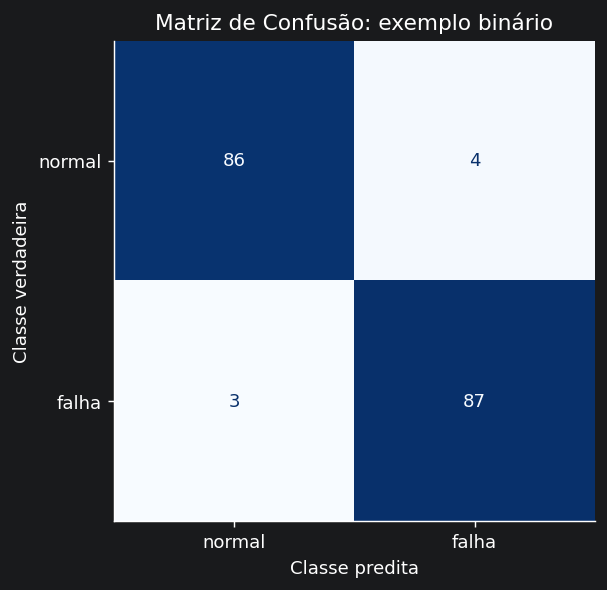

In [6]:
# Figura 4: matriz de confusao do exemplo binario.
y_true = y
y_pred = clf.predict(X)
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5.5, 4.8))
disp = ConfusionMatrixDisplay(cm, display_labels=["normal", "falha"])
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Matriz de Confusão: exemplo binário")
ax.set_xlabel("Classe predita")
ax.set_ylabel("Classe verdadeira")
ax.grid(False)
savefig("matriz_confusao")

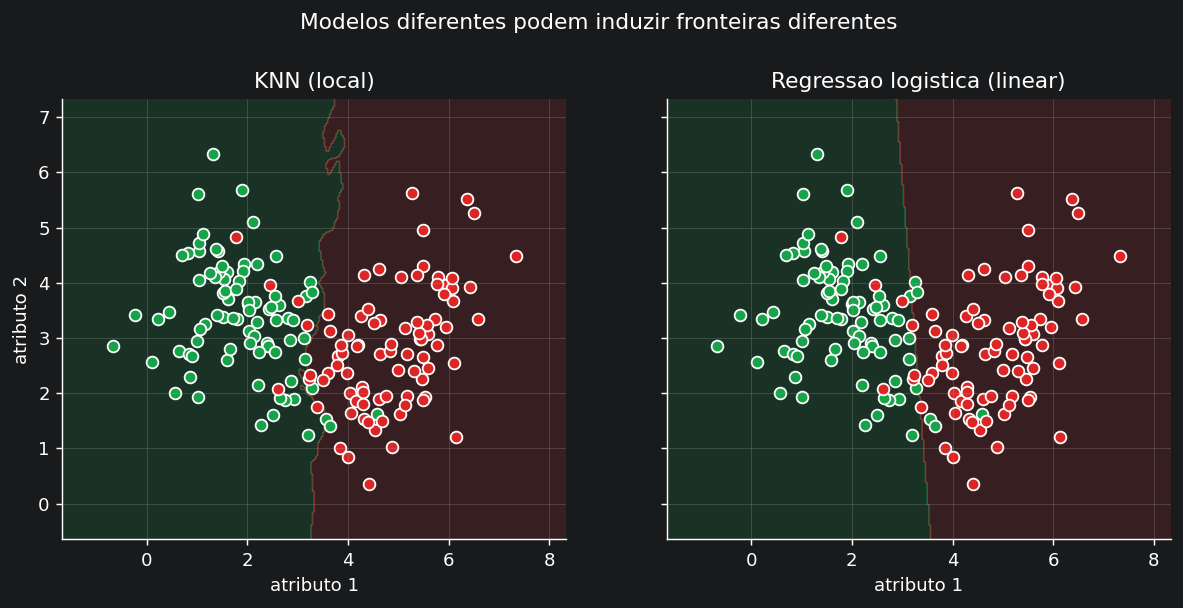

In [7]:
# Figura 5: comparacao qualitativa entre duas fronteiras simples.
X2, y2 = make_blobs(
    n_samples=170,
    centers=[(2.0, 3.0), (4.8, 3.4)],
    cluster_std=[0.85, 1.0],
    random_state=12,
)
X2[:, 1] += 0.9 * np.sin(1.1 * X2[:, 0])
models = {
    "KNN (local)": KNeighborsClassifier(n_neighbors=9),
    "Regressao logistica (linear)": LogisticRegression(),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True, sharey=True)
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X2, y2)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.14, cmap=ListedColormap(["#22c55e", "#ef4444"]))
    ax.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], c="#16a34a", edgecolor="white", s=42)
    ax.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], c="#dc2626", edgecolor="white", s=42)
    ax.set_title(name)
    ax.set_xlabel("atributo 1")
axes[0].set_ylabel("atributo 2")
fig.suptitle("Modelos diferentes podem induzir fronteiras diferentes", y=1.03)
savefig("fronteiras_modelos")

In [8]:
# Separa os dados em treino e teste
# random_state=1 faz com que a divisão aleatória possa ser repetida depois, gerando sempre o mesmo resultado
# stratify=y faz com que treino e teste mantenham aproximadamente a mesma proporção de classes do conjunto original
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)

# Cria o modelo de classificação
modelo = LogisticRegression()

# Ajusta o modelo aos dados de treino
modelo.fit(X_train, y_train)

# Calcula a acurácia no conjunto de teste
acuracia = modelo.score(X_test, y_test)

# Exibe a acurácia obtida
print(f"Acuracia no conjunto de teste: {acuracia:.3f}")

# Mostra as previsões para 8 amostras de teste
print("Primeiras previsoes:", modelo.predict(X_test[:8]))

Acuracia no conjunto de teste: 0.944
Primeiras previsoes: [1 1 1 0 0 1 1 0]
